# PSF Convolution and FWHM Comparison (Document-20160)

This notebook verifies the OpSim empirical combining formula from Xin, Angeli & Ivezić (2016).

The paper shows that for a VonKarman atmospheric PSF convolved with a Gaussian system PSF,
the total FWHM is **not** a simple quadrature sum. Instead (Eqs 4.3–4.4):

$$\mathrm{FWHM_{eff}} = 1.16\,\sqrt{\mathrm{FWHM_{sys}^2} + 1.04\,\mathrm{FWHM_{atm}^2}}$$
$$\mathrm{FWHM_{tot}} = 0.822\,\mathrm{FWHM_{eff}} + 0.052$$

Both components degrade with airmass $X = \sec(z)$:

$$r_0(\lambda, X) = r_0(500, X{=}1)\left(\frac{\lambda}{500}\right)^{6/5} X^{-3/5} \quad\text{(Eq 3.2)}$$
$$\mathrm{FWHM_{sys}}(X) = \mathrm{FWHM_{sys,0}}\; X^{3/5} \quad\text{(Eq 3.6)}$$

**LSST reference parameters (Sec. 2):** L₀ = 30 m, FWHMsys₀ = 0.4″ at zenith/500 nm.

In [21]:
import galsim
import numpy as np
import matplotlib.pyplot as plt

In [31]:
# --- Baseline parameters (Document-20160, Sec. 2 & 3) ---
lam       = 500.0  # wavelength [nm], LSST reference
r0_m      = 0.15   # Fried parameter at zenith / 500 nm [m]
L0_m      = 30.0   # outer scale [m], LSST site value (Sec. 2.1)
fwhm_sys0 = np.sqrt(0.30**2 + 0.25**2 + 0.08**2)  # system FWHM at zenith [arcsec] = 0.4"

# Airmass (X = sec(z)); X=1 → zenith, X=2 → z ≈ 60°
X = 1.2

# Eq 3.2 — r0 scales with airmass (at fixed lam=500nm, (lam/500)^(6/5)=1)
r0_scaled = r0_m * X**(-0.6)

# Eq 3.6 — system FWHM scales with airmass
fwhm_sys = fwhm_sys0 * X**0.6

# Eq 3.3 — analytic atmospheric FWHM (outer-scale-corrected VonKarman)
# r0 and L0 must be in consistent units; formula uses cm internally
def fwhm_atm_analytic(lam_nm, r0_meters, L0_meters=30.0):
    r0_cm = r0_meters * 100.0
    L0_cm = L0_meters * 100.0
    fwhm0 = 0.976 * 2.063e-2 * (lam_nm / r0_cm)
    outer_scale_corr = np.sqrt(1.0 - 2.183 * (r0_cm / L0_cm)**0.356)
    return fwhm0 * outer_scale_corr

fwhm_atm_eq33 = fwhm_atm_analytic(lam, r0_scaled, L0_m)
print(f"Airmass X = {X:.2f}  (zenith angle {np.degrees(np.arccos(1/X)):.1f}°)")
print(f"r0 (scaled)               : {r0_scaled*100:.2f} cm")
print(f"FWHMatm  (Eq 3.3 analytic): {fwhm_atm_eq33:.4f} arcsec")
print(f"FWHMsys  (Eq 3.6 scaled)  : {fwhm_sys:.4f} arcsec")

# --- GalSim PSF objects at this airmass ---
atm_psf   = galsim.VonKarman(lam=lam, r0=r0_scaled, L0=L0_m)
sys_psf   = galsim.Gaussian(fwhm=fwhm_sys)
total_psf = galsim.Convolve([atm_psf, sys_psf])

Airmass X = 1.20  (zenith angle 33.6°)
r0 (scaled)               : 13.45 cm
FWHMatm  (Eq 3.3 analytic): 0.6182 arcsec
FWHMsys  (Eq 3.6 scaled)  : 0.4447 arcsec


In [32]:
scale = 0.02   # arcsec/pixel — fine enough to resolve 0.4" features
npix  = 512    # 10.24" field of view

def measure_fwhm(profile, npix=512, scale=0.02):
    """Measure FWHM from the radial profile of a drawn image."""
    img = profile.drawImage(nx=npix, ny=npix, scale=scale)
    arr = img.array
    cy, cx = np.unravel_index(arr.argmax(), arr.shape)

    y, x = np.indices(arr.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2) * scale

    r_flat   = r.ravel()
    v_flat   = arr.ravel() / arr.max()
    order    = np.argsort(r_flat)
    r_sorted = r_flat[order]
    v_sorted = v_flat[order]

    half_r = np.interp(0.5, v_sorted[::-1], r_sorted[::-1])
    return 2.0 * half_r

# Measure GalSim FWHMs
fwhm_atm_galsim = measure_fwhm(atm_psf)
fwhm_sys_galsim = measure_fwhm(sys_psf)
fwhm_tot_galsim = measure_fwhm(total_psf)

# --- Document-20160 prediction (Eqs 4.3 & 4.4) ---
fwhm_eff_pred = 1.16 * np.sqrt(fwhm_sys**2 + 1.04 * fwhm_atm_eq33**2)
fwhm_tot_pred = 0.822 * fwhm_eff_pred + 0.052

# --- Naive Gaussian quadrature (exact only if both components were Gaussian) ---
fwhm_quad = np.sqrt(fwhm_atm_eq33**2 + fwhm_sys**2)

# --- Summary ---
print(f"{'':30s} {'arcsec':>8}")
print("-" * 40)
print(f"{'FWHMatm  (Eq 3.3 analytic)':30s} {fwhm_atm_eq33:8.4f}")
print(f"{'FWHMatm  (GalSim measured)':30s} {fwhm_atm_galsim:8.4f}")
print(f"{'FWHMsys  (Gaussian spec)':30s} {fwhm_sys:8.4f}")
print(f"{'FWHMsys  (GalSim measured)':30s} {fwhm_sys_galsim:8.4f}")
print("-" * 40)
print(f"{'FWHMtot  (GalSim convolution)':30s} {fwhm_tot_galsim:8.4f}  <-- ground truth")
print(f"{'FWHMtot  (Doc-20160 Eqs 4.3+4.4)':30s} {fwhm_tot_pred:8.4f}  <-- paper prediction")
print(f"{'FWHMtot  (naive quadrature)':30s} {fwhm_quad:8.4f}  <-- Gaussian approx")
print("-" * 40)
print(f"{'Paper residual':30s} {fwhm_tot_galsim - fwhm_tot_pred:+8.4f} arcsec")
print(f"{'Quadrature residual':30s} {fwhm_tot_galsim - fwhm_quad:+8.4f} arcsec")

                                 arcsec
----------------------------------------
FWHMatm  (Eq 3.3 analytic)       0.6182
FWHMatm  (GalSim measured)       0.6261
FWHMsys  (Gaussian spec)         0.4447
FWHMsys  (GalSim measured)       0.4327
----------------------------------------
FWHMtot  (GalSim convolution)    0.7970  <-- ground truth
FWHMtot  (Doc-20160 Eqs 4.3+4.4)   0.7876  <-- paper prediction
FWHMtot  (naive quadrature)      0.7615  <-- Gaussian approx
----------------------------------------
Paper residual                  +0.0094 arcsec
Quadrature residual             +0.0355 arcsec


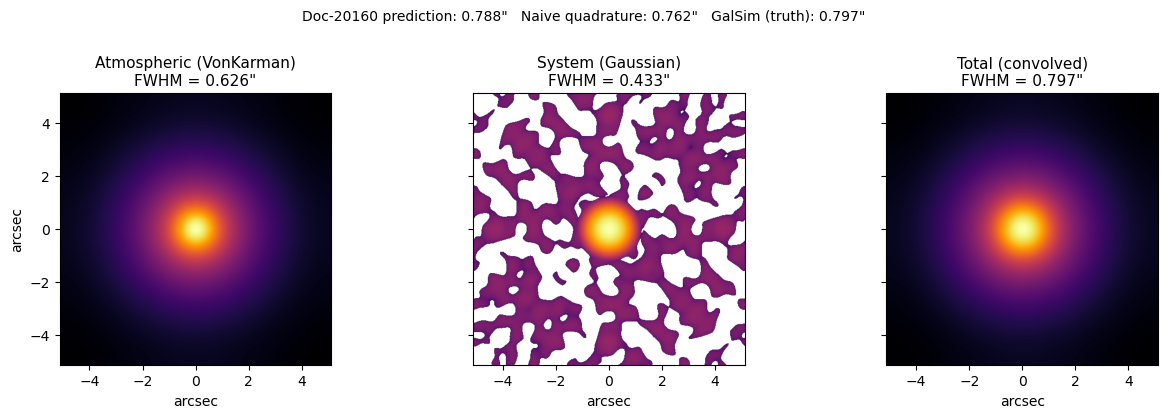

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

profiles = [
    (atm_psf,   f"Atmospheric (VonKarman)\nFWHM = {fwhm_atm_galsim:.3f}\""),
    (sys_psf,   f"System (Gaussian)\nFWHM = {fwhm_sys_galsim:.3f}\""),
    (total_psf, f"Total (convolved)\nFWHM = {fwhm_tot_galsim:.3f}\""),
]

for ax, (psf, title) in zip(axes, profiles):
    img = psf.drawImage(nx=npix, ny=npix, scale=scale).array
    extent = npix * scale / 2
    ax.imshow(img, origin='lower', extent=[-extent, extent, -extent, extent],
              cmap='inferno', norm=plt.matplotlib.colors.LogNorm())
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('arcsec')

axes[0].set_ylabel('arcsec')
plt.suptitle(
    f"Doc-20160 prediction: {fwhm_tot_pred:.3f}\"   "
    f"Naive quadrature: {fwhm_quad:.3f}\"   "
    f"GalSim (truth): {fwhm_tot_galsim:.3f}\"",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

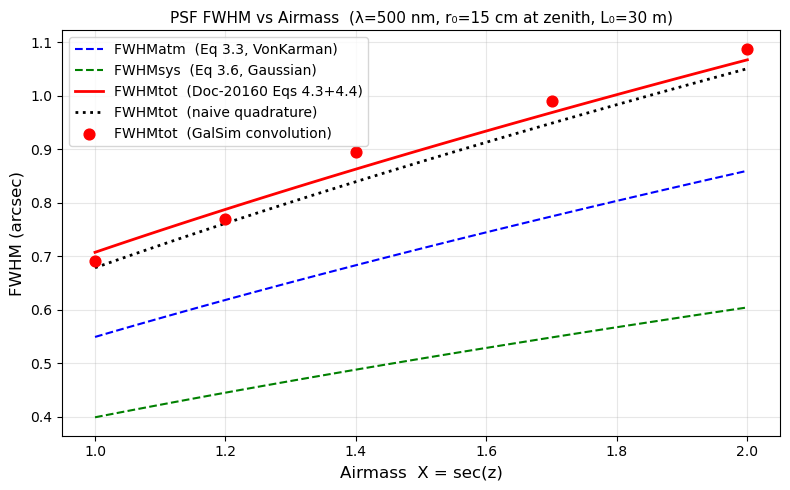

In [34]:
# --- Airmass sweep: X from 1.0 (zenith) to 2.0 (z ≈ 60°) ---
X_arr = np.linspace(1.0, 2.0, 40)

fwhm_atm_sweep = np.zeros(len(X_arr))
fwhm_sys_sweep = np.zeros(len(X_arr))
fwhm_tot_paper = np.zeros(len(X_arr))
fwhm_tot_quad  = np.zeros(len(X_arr))

for i, Xi in enumerate(X_arr):
    r0_x = r0_m * Xi**(-0.6)                           # Eq 3.2
    fa   = fwhm_atm_analytic(lam, r0_x, L0_m)          # Eq 3.3
    fs   = fwhm_sys0 * Xi**0.6                          # Eq 3.6
    fe   = 1.16 * np.sqrt(fs**2 + 1.04 * fa**2)        # Eq 4.3
    fwhm_atm_sweep[i] = fa
    fwhm_sys_sweep[i] = fs
    fwhm_tot_paper[i] = 0.822 * fe + 0.052             # Eq 4.4
    fwhm_tot_quad[i]  = np.sqrt(fa**2 + fs**2)

# GalSim validation at 5 airmass values
X_gs = [1.0, 1.2, 1.4, 1.7, 2.0]
fwhm_gs = []
for Xi in X_gs:
    ap = galsim.VonKarman(lam=lam, r0=r0_m * Xi**(-0.6), L0=L0_m)
    sp = galsim.Gaussian(fwhm=fwhm_sys0 * Xi**0.6)
    fwhm_gs.append(measure_fwhm(galsim.Convolve([ap, sp]), npix=256, scale=0.02))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(X_arr, fwhm_atm_sweep, 'b--', lw=1.5, label='FWHMatm  (Eq 3.3, VonKarman)')
ax.plot(X_arr, fwhm_sys_sweep, 'g--', lw=1.5, label='FWHMsys  (Eq 3.6, Gaussian)')
ax.plot(X_arr, fwhm_tot_paper, 'r-',  lw=2,   label='FWHMtot  (Doc-20160 Eqs 4.3+4.4)')
ax.plot(X_arr, fwhm_tot_quad,  'k:',  lw=2,   label='FWHMtot  (naive quadrature)')
ax.scatter(X_gs, fwhm_gs, c='red', zorder=5, s=60, label='FWHMtot  (GalSim convolution)')

ax.set_xlabel('Airmass  X = sec(z)', fontsize=12)
ax.set_ylabel('FWHM (arcsec)', fontsize=12)
ax.set_title(f'PSF FWHM vs Airmass  (λ=500 nm, r₀={r0_m*100:.0f} cm at zenith, L₀={L0_m:.0f} m)',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()